# Category 2: Prescriptive Analysis


In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import os


In [4]:
import os

print(os.getcwd())

C:\Users\haris


In [5]:
import os

folder = r"C:\Users\haris\OneDrive\Desktop\SUGANYA\DA215\Python\Python_Hackathon_Sep_2026\cardiac_failure"

os.chdir(folder)

print(os.getcwd())

C:\Users\haris\OneDrive\Desktop\SUGANYA\DA215\Python\Python_Hackathon_Sep_2026\cardiac_failure


In [6]:
for file in os.listdir():
    if file.lower().endswith('.csv'):
        print(file)

cardiac_complications.csv
demography.csv
hospitalization_discharge.csv
labs.csv
patienthistory.csv
patienthistory_cleaned.csv
patient_precriptions.csv
responsivenes.csv
Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv
Team7_CodeAvengers_Category1_DataCleaning_demography.csv
Team7_CodeAvengers_Category1_DataCleaning_labs.csv
Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv
Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv
Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv


In [7]:
# Patient History
df = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv"
)

# Cardiac Complications
cardiac = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv"
)

# Demography
demography = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_demography.csv"
)

# Laboratory
labs = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_labs.csv"
)

# Patient Prescriptions
prescriptions = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv"
)

# Responsiveness
responsiveness = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv"
)

In [30]:
print(df.shape)
print(cardiac.shape)
print(demography.shape)
print(labs.shape)
print(responsiveness.shape)

(2008, 18)
(2008, 14)
(2008, 7)
(2008, 107)
(2008, 6)


### Question 1: Which patients have a high comorbidity burden?
 Reasoning: Patients with multiple recorded comorbidities may represent a more complex clinical population. Identifying patients with higher CCI scores and multiple coexisting conditions can help define groups that may benefit from additional review or monitoring.

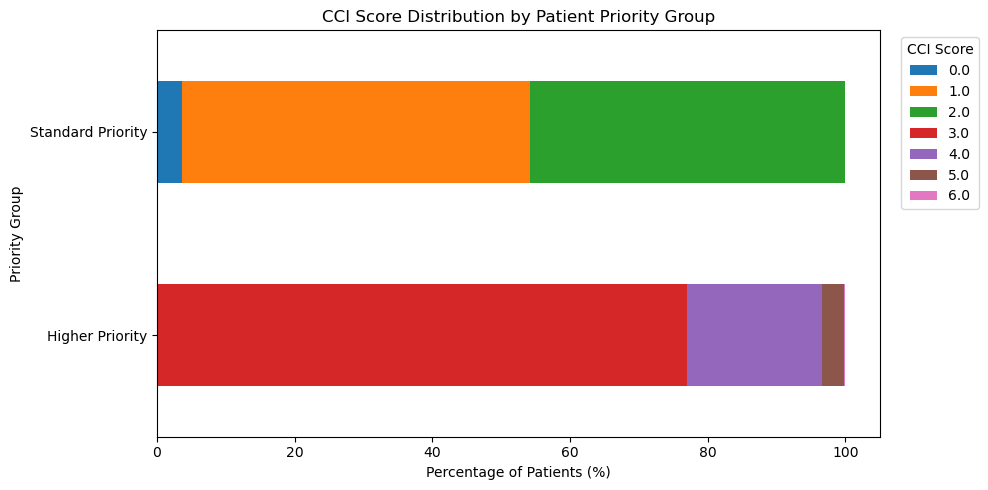

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Create priority group
df['priority_group'] = np.where(
    df['cci_score'] >= 3,
    'Higher Priority',
    'Standard Priority'
)

# Create cross-tabulation
priority_cci = pd.crosstab(
    df['priority_group'],
    df['cci_score'],
    normalize='index'
) * 100

# Plot
priority_cci.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5)
)

plt.title('CCI Score Distribution by Patient Priority Group')
plt.xlabel('Percentage of Patients (%)')
plt.ylabel('Priority Group')

plt.legend(
    title='CCI Score',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Key Insights
 The **Standard Priority** group contains patients with CCI scores of **0–2**, with scores **1 and 2** making up the majority of this group. The **Higher Priority** group contains patients with CCI scores of **3 or above* Within the Higher Priority group, **CCI score 3 is dominant**, representing roughly three-quarters of these patients, while scores **4 and 5** are less common. Very high CCI scores are rare, indicating that only a small proportion of patients have an extremely high comorbidity burden.


### Question 2: Which comorbidity combinations could be prioritized?
 Reasoning: Patients may have several chronic conditions simultaneously. Examining co-occurring diabetes and chronic kidney disease helps identify a subgroup with multiple important comorbidities that may warrant closer review in subsequent outcome analyses.

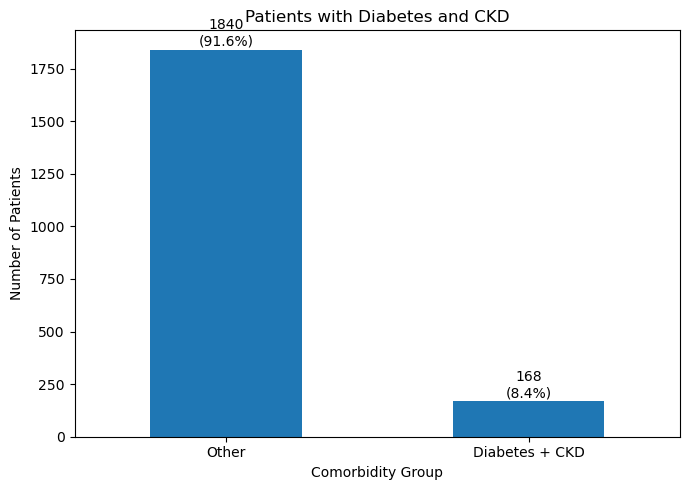

In [25]:
# visualization:

# Count patients in each group
group_counts = df['diabetes_ckd_group'].value_counts()

# Calculate percentages
group_percent = group_counts / group_counts.sum() * 100

# Create bar chart
ax = group_counts.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Patients with Diabetes and CKD')
plt.xlabel('Comorbidity Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

# Add count and percentage labels
for i, count in enumerate(group_counts):
    percentage = group_percent.iloc[i]
    ax.text(
        i,
        count + 20,
        f'{count}\n({percentage:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Key Insights
 Out of **2,008 heart-failure patients**, **168 patients (8.4%)** have both **diabetes and moderate-to-severe chronic kidney disease (CKD)**. The remaining **1,840 patients (91.6%)** do not have this specific combination of conditions.This shows that approximately **1 in 12 patients** has both diabetes and CKD.Although this subgroup represents a relatively small proportion of the population, the combination identifies patients with **multiple important comorbidities**.

### Question 3: What is the distribution of CCI scores?
##### Reasoning: This describes whether the population is concentrated at lower or higher levels of overall comorbidity burden.

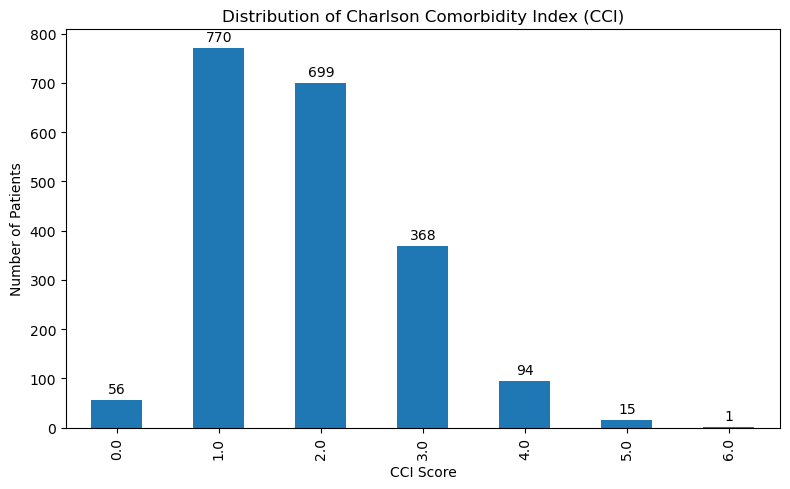

In [26]:
cci_distribution = (
    df['cci_score']
    .value_counts()
    .sort_index()
)

ax = cci_distribution.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Distribution of Charlson Comorbidity Index (CCI)')
plt.xlabel('CCI Score')
plt.ylabel('Number of Patients')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Key Insights
The majority of heart-failure patients have relatively **low-to-moderate CCI scores**, with **CCI 1 (770 patients)** and **CCI 2 (699 patients)** being the most common. **368 patients** have a CCI score of **3**, while the number of patients decreases substantially at higher CCI scores.Only **94 patients** have a CCI score of 4, **15 patients** have a score of 5, and just **1 patient** has a score of 6.Overall, **478 patients (23.8%) have CCI scores of 3 or higher**, indicating that nearly **1 in 4 patients** falls into the higher-comorbidity-burden group based on the threshold used in this analysis. The distribution is concentrated around **CCI scores 1–2**, while very high comorbidity scores are relatively rare in this dataset.

In [37]:
combined = (
    df
    .merge(demography, on='inpatient_number', how='inner')
    .merge(cardiac, on='inpatient_number', how='inner')
    .merge(labs, on='inpatient_number', how='inner')
    .merge(responsiveness, on='inpatient_number', how='inner')
)

print("Rows:", combined.shape[0])
print("Columns:", combined.shape[1])

Rows: 2008
Columns: 148


In [38]:
combined.head()

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,...,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,0,0,1,0,0.0,1,0.0,0,0,...,93.0,95.9,17.8,1.14,125.0,4,5,6,Clear,15
1,743087,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
2,866418,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
3,775928,0,0,1,0,0.0,0,1.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
4,810128,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15


In [39]:
combined.columns.tolist()

['inpatient_number',
 'cerebrovascular_disease',
 'dementia',
 'chronic_obstructive_pulmonary_disease',
 'connective_tissue_disease',
 'peptic_ulcer_disease',
 'diabetes',
 'moderate_to_severe_chronic_kidney_disease',
 'hemiplegia',
 'leukemia',
 'malignant_lymphoma',
 'solid_tumor',
 'liver_disease',
 'aids',
 'cci_score',
 'type_ii_respiratory_failure',
 'acute_renal_failure',
 'diabetes_ckd_group',
 'gender',
 'weight',
 'height',
 'bmi',
 'occupation',
 'agecat',
 'nyha_cardiac_function_classification',
 'killip_grade',
 'myocardial_infarction',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'type_of_heart_failure',
 'lvef',
 'left_ventricular_end_diastolic_diameter_lv',
 'mitral_valve_ems',
 'mitral_valve_ams',
 'ea',
 'tricuspid_valve_return_velocity',
 'tricuspid_valve_return_pressure',
 'body_temperature',
 'pulse',
 'respiration',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'map_value',
 'fio2',
 'creatinine_enzymatic_method',
 'urea',
 'uric_acid'

### Question 4: Which patients have high comorbidity burden AND impaired cardiac function?
Reasoning: Comorbidity burden and cardiac function provide different information about patient complexity. Examining them together can identify patients who have multiple chronic conditions alongside impaired cardiac function.

In [40]:
cardiac.columns.tolist()

['inpatient_number',
 'nyha_cardiac_function_classification',
 'killip_grade',
 'myocardial_infarction',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'type_of_heart_failure',
 'lvef',
 'left_ventricular_end_diastolic_diameter_lv',
 'mitral_valve_ems',
 'mitral_valve_ams',
 'ea',
 'tricuspid_valve_return_velocity',
 'tricuspid_valve_return_pressure']

In [41]:
combined[['cci_score', 'lvef']].describe()

,cci_score,lvef
count,2003.000000,635.000000
mean,1.861707,50.682992
std,0.961469,13.221701
min,0.000000,5.000000
25%,1.000000,41.000000
50%,2.000000,51.000000
75%,2.000000,61.000000
max,6.000000,82.000000


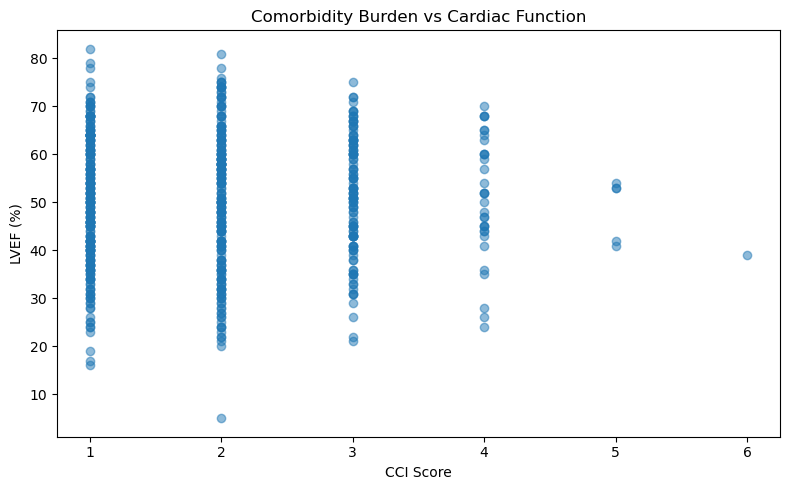

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    combined['cci_score'],
    combined['lvef'],
    alpha=0.5
)

plt.title('Comorbidity Burden vs Cardiac Function')
plt.xlabel('CCI Score')
plt.ylabel('LVEF (%)')

plt.tight_layout()
plt.show()

### Key Insights
LVEF values vary widely among patients with lower CCI scores, particularly for **CCI scores 1 and 2**, showing substantial variation in cardiac function within these groups.As CCI scores increase, the number of patients becomes much smaller, which is consistent with the CCI distribution in this dataset. Patients with **CCI scores 3 and 4** still show a broad range of LVEF values, so a clear decline in LVEF with increasing comorbidity burden is not visually evident.Very high CCI scores (**5–6**) contain only a few patients, so their LVEF values should be interpreted cautiously and should not be generalized to the overall population.

### Question 5: Which age groups have greater clinical complexity?
 Reasoning: Age can be examined together with comorbidity burden, cardiac function, and laboratory measurements to identify demographic groups with more complex clinical profiles.This information can support prioritization of groups for closer monitoring and further assessment.

In [44]:
age_summary = (
    combined.groupby('agecat')
    .agg(
        Patients=('inpatient_number', 'count'),
        Average_CCI=('cci_score', 'mean'),
        Median_CCI=('cci_score', 'median')
    )
)

age_summary.round(2)

,Patients,Average_CCI,Median_CCI
agecat,,,
21-29,4,1.00,1.0
29-39,12,1.33,1.0
39-49,56,1.62,1.0
49-59,106,1.59,1.0
59-69,368,1.77,2.0
69-79,715,1.89,2.0
79-89,646,1.93,2.0
89-110,101,2.04,2.0


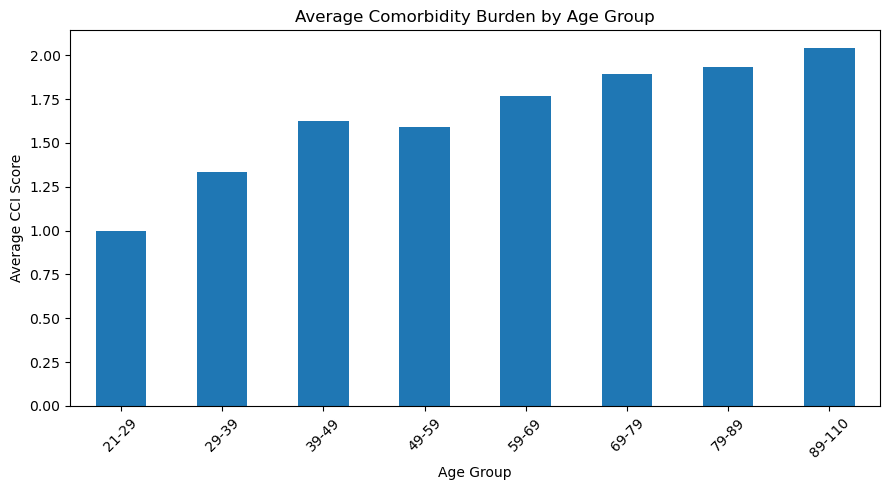

In [45]:
ax = age_summary['Average_CCI'].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Comorbidity Burden by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CCI Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insights
 The **average CCI score generally increases with age**, indicating that older heart-failure patients tend to have a higher comorbidity burden.The **21–29 age group** has the lowest average CCI score at approximately **1.0**.
Average CCI gradually rises across the older age groups, reaching approximately **2.0 in the 89–110 age group**, the highest level observed.There is a small decrease between the **39–49 and 49–59 age groups**, but the overall pattern remains upward with increasing age.Patients aged **69 years and above** show comparatively higher average CCI scores, suggesting a greater concentration of coexisting health conditions in older patients.Overall, the analysis shows an **association between increasing age and greater comorbidity burden** in this heart-failure population.

### Qustion 6: Which kidney-related laboratory measurements are most strongly correlated?
 Reasoning: Creatinine, eGFR, and urea are commonly used to assess kidney function.Examining the correlations among these measurements helps identify how changes in one laboratory measure are associated with changes in another.Understanding these relationships can help identify groups of related kidney-function indicators that may be useful for closer monitoring of heart failure patients.

In [46]:
lab_vars = [
    'creatinine_enzymatic_method',
    'glomerular_filtration_rate',
    'urea'
]

correlation = combined[lab_vars].corr()

correlation.round(2)

,creatinine_enzymatic_method,glomerular_filtration_rate,urea
creatinine_enzymatic_method,1.00,-0.67,0.67
glomerular_filtration_rate,-0.67,1.00,-0.58
urea,0.67,-0.58,1.00


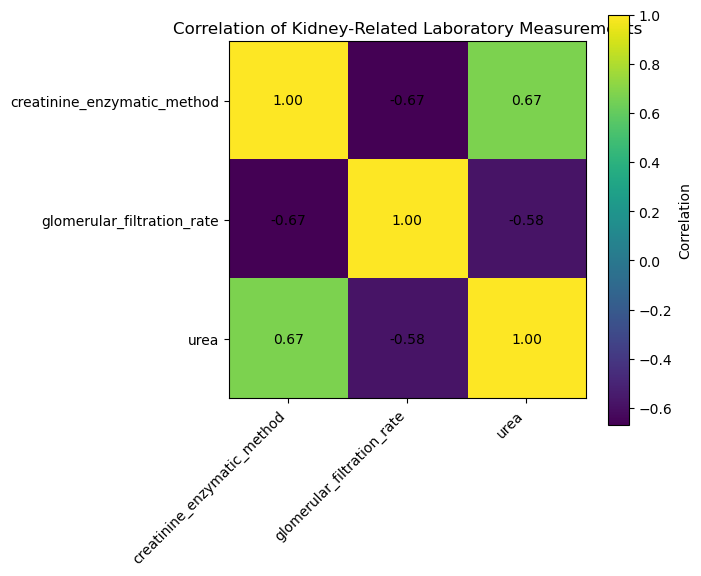

In [47]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(correlation)

ax.set_xticks(range(len(lab_vars)))
ax.set_yticks(range(len(lab_vars)))

ax.set_xticklabels(lab_vars, rotation=45, ha='right')
ax.set_yticklabels(lab_vars)

for i in range(len(lab_vars)):
    for j in range(len(lab_vars)):
        ax.text(
            j,
            i,
            f'{correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.colorbar(image, label='Correlation')
plt.title('Correlation of Kidney-Related Laboratory Measurements')

plt.tight_layout()
plt.show()

### Key Insights
 **Creatinine and urea show a positive correlation (0.67)**, indicating that higher creatinine levels tend to be associated with higher urea levels.**Creatinine and glomerular filtration rate (eGFR) show a negative correlation (-0.67)**, meaning that higher creatinine tends to be associated with lower kidney filtration rate.**Urea and eGFR also show a negative correlation (-0.58)**, suggesting that higher urea levels tend to occur alongside lower filtration rates.Among the relationships examined, **creatinine–urea and creatinine–eGFR show the strongest correlations**.